In [55]:
import keras
model=keras.models.load_model('best-model.keras')

In [56]:
model.layers

[<Conv2D name=conv2d, built=True>,
 <MaxPooling2D name=max_pooling2d, built=True>,
 <Conv2D name=conv2d_1, built=True>,
 <MaxPooling2D name=max_pooling2d_1, built=True>,
 <Flatten name=flatten, built=True>,
 <Dense name=dense, built=True>,
 <Dropout name=dropout, built=True>,
 <Dense name=dense_1, built=True>]

In [57]:
conv = model.layers[0]
print(conv.weights[0].shape,conv.weights[1].shape)

(3, 3, 1, 32) (32,)


In [58]:
conv_weights = conv.weights[0].numpy()
print(conv_weights.mean(), conv_weights.std())

-0.043813687 0.21005626


In [59]:
conv_weights

array([[[[-1.19983993e-01, -7.86928013e-02,  2.04812456e-02,
          -3.47461328e-02,  1.77313805e-01, -2.10516274e-01,
           5.49159991e-03, -7.49043152e-02, -5.42156175e-02,
          -1.56507060e-01, -5.92197739e-02, -7.75035918e-02,
           1.80013061e-01, -2.92261671e-02,  3.60570289e-03,
          -5.47224432e-02, -4.65310633e-01, -9.73754749e-02,
          -1.53363973e-01,  2.50190143e-02,  1.04964182e-01,
           1.43991977e-01,  3.32027078e-02,  8.18471685e-02,
          -1.72165371e-02,  2.21315008e-02,  4.35166135e-02,
           6.59092590e-02,  1.86731681e-01,  1.41017646e-01,
          -4.92598921e-01,  8.61054584e-02]],

        [[ 2.27171674e-01,  2.36911308e-02,  5.96269257e-02,
          -5.36166579e-02,  1.21657610e-01,  1.94806725e-01,
          -8.33370805e-01, -6.15679026e-02,  1.43478304e-01,
          -1.13465935e-01, -7.30653927e-02,  6.08525202e-02,
           2.81095430e-02,  8.13183635e-02,  3.00825685e-01,
           1.20300643e-01, -6.97417185

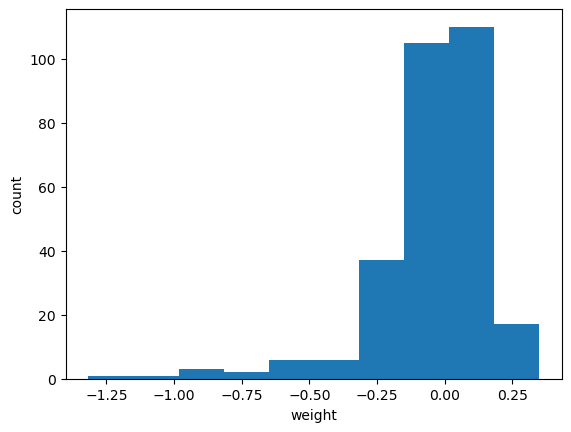

In [60]:
import matplotlib.pyplot as plt

plt.hist(conv_weights.reshape(-1,1))
plt.xlabel('weight')
plt.ylabel('count')
plt.show()

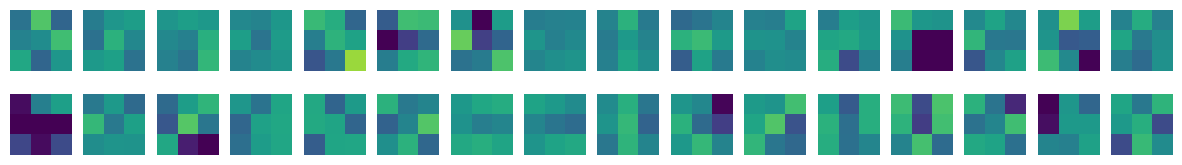

In [61]:
fig, axs = plt.subplots(2, 16, figsize=(15,2))
for i in range(2):
    for j in range(16):
        axs[i, j].imshow(conv_weights[:,:,0,i*16+j], vmin=-0.5, vmax=0.5)
                                    # 행 열 깊이 
        axs[i, j].axis('off')

plt.show()

In [62]:
conv_weights[:,:,0,i*0+j]

array([[-0.05472244,  0.12030064, -0.06007381],
       [ 0.08942834, -0.09598915, -0.00409683],
       [-0.07162671, -0.15183364,  0.00724657]], dtype=float32)

In [63]:
model2 = keras.Sequential()
model2.add(keras.layers.Input(shape=(28,28,1)))
model2.add(keras.layers.Conv2D(32, kernel_size=3, activation='relu', padding='same'))
 # 3 * 3 = 가중치 9개


In [64]:
model2.layers

[<Conv2D name=conv2d_2, built=True>]

In [65]:
conv2 = model2.layers[0]
print(conv2.weights[0].shape,conv2.weights[1].shape)

(3, 3, 1, 32) (32,)


In [66]:
conv2_weights = conv2.weights[0].numpy()
print(conv2_weights.mean(), conv2_weights.std())

0.003889434 0.07857876


In [67]:
conv2_weights

array([[[[ 0.00204009,  0.00953627, -0.13131037, -0.00244313,
           0.05177128,  0.09765197,  0.11666013,  0.13977043,
          -0.0970275 ,  0.01373173, -0.01945228, -0.13311669,
          -0.01058017,  0.11281858, -0.12231955,  0.13276823,
           0.04491127, -0.0631147 ,  0.06720653, -0.11382538,
           0.05395289, -0.1282546 , -0.03196376,  0.04531324,
           0.13895048, -0.10588419,  0.01603881,  0.14128189,
           0.04782972,  0.0619625 ,  0.10615197,  0.05646892]],

        [[-0.0492437 ,  0.01060335, -0.06215681, -0.04150037,
          -0.05244022,  0.05745433,  0.11864014, -0.04300107,
           0.05878322, -0.02860516, -0.08443353,  0.03540139,
           0.0480698 ,  0.06140922,  0.06656615,  0.08468714,
           0.08875224,  0.06867523, -0.03031067,  0.11001648,
           0.01986594, -0.10390387,  0.01799676,  0.02591497,
           0.0091995 ,  0.03590584, -0.08636789, -0.12612978,
           0.02659753,  0.11665352,  0.12940659, -0.11997925]],

  

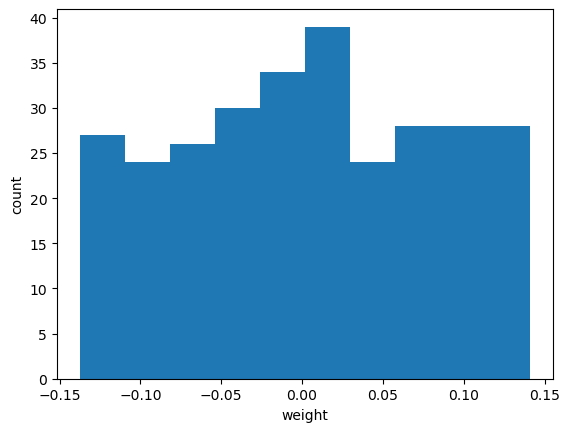

In [68]:
import matplotlib.pyplot as plt

plt.hist(conv2_weights.reshape(-1,1))
plt.xlabel('weight')
plt.ylabel('count')
plt.show()

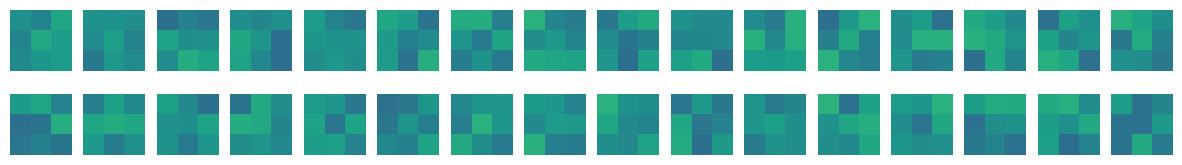

In [69]:
fig, axs = plt.subplots(2, 16, figsize=(15,2))
for i in range(2):
    for j in range(16):
        axs[i, j].imshow(conv2_weights[:,:,0,i*16+j], vmin=-0.5, vmax=0.5)
        axs[i, j].axis('off')

plt.show()

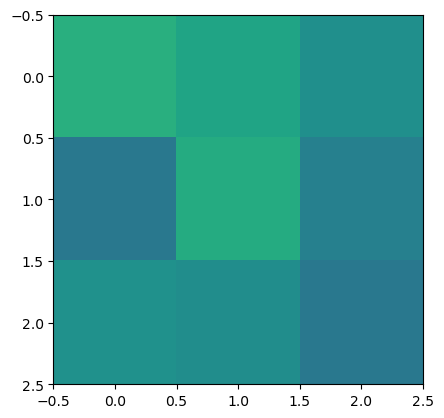

In [70]:
plt.imshow(conv2_weights[:,:,0,i*0+j], vmin=-0.5, vmax=0.5)


In [71]:
conv2_weights[:,:,0,i*0+j]

array([[ 0.13276823,  0.08468714, -0.00266266],
       [-0.09879875,  0.11349629, -0.06553592],
       [ 0.00613452, -0.00998114, -0.10028946]], dtype=float32)

In [72]:
inputs = keras.Input(shape=(784,))
dense1 = keras.layers.Dense(100, activation='relu')
dense2 = keras.layers.Dense(10, activation='softmax')


In [73]:
hidden = dense1(inputs)


In [74]:
outputs = dense2(hidden)


In [75]:
func_model = keras.Model(inputs, outputs)


In [76]:
print(model.inputs)


[<KerasTensor shape=(None, 28, 28, 1), dtype=float32, sparse=False, ragged=False, name=input_layer>]


In [77]:
conv_acti = keras.Model(model.inputs, model.layers[0].output)


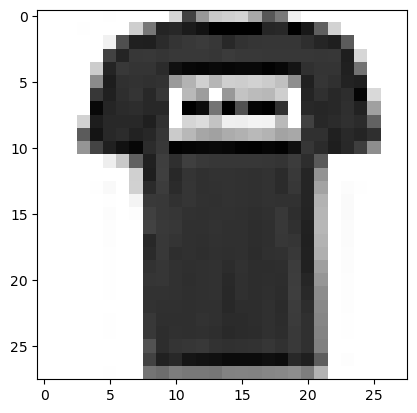

In [85]:
(train_input, train_target), (test_input, test_target) =\
        keras.datasets.fashion_mnist.load_data()
plt.imshow(train_input[1], cmap='gray_r')
plt.show()


In [88]:
ankle_boot = train_input[1:2].reshape(-1, 28, 28, 1) / 255.0
feature_maps = conv_acti.predict(ankle_boot)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


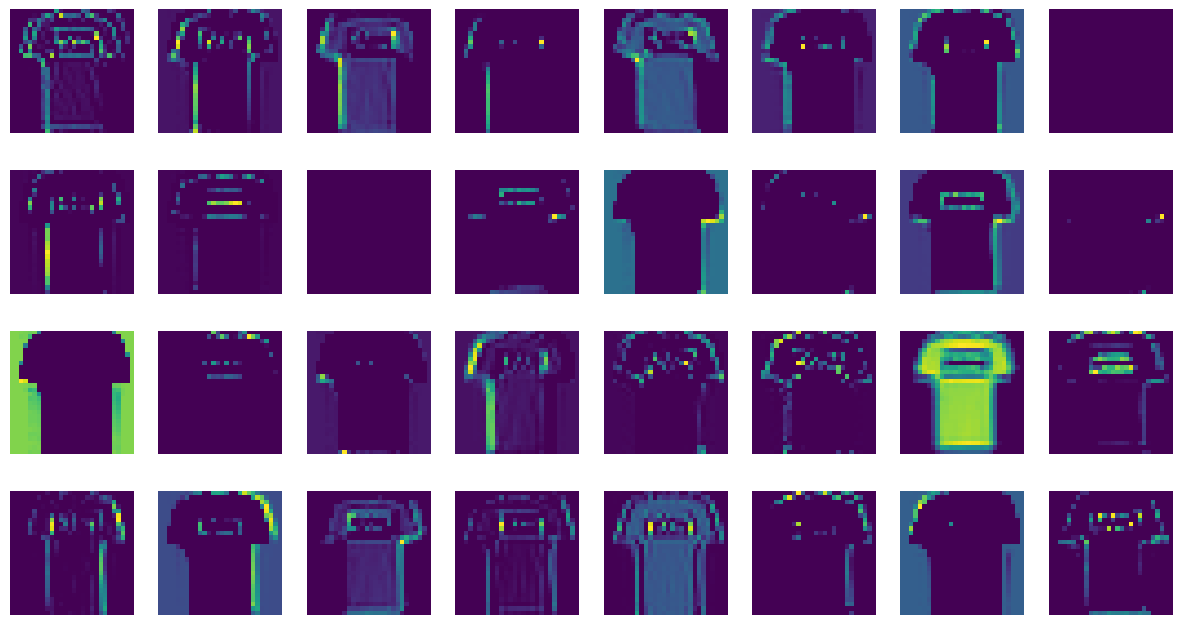

In [89]:
fig, axs = plt.subplots(4, 8, figsize=(15,8))
for i in range(4):
    for j in range(8):
         axs[i, j].imshow(feature_maps[0,:,:,i*8 + j])
         axs[i, j].axis('off')
plt.show()


In [81]:
conv2_acti = keras.Model(model.inputs, model.layers[2].output)


In [82]:
feature_maps = conv2_acti.predict(ankle_boot)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step


In [83]:
feature_maps = conv2_acti.predict(ankle_boot)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


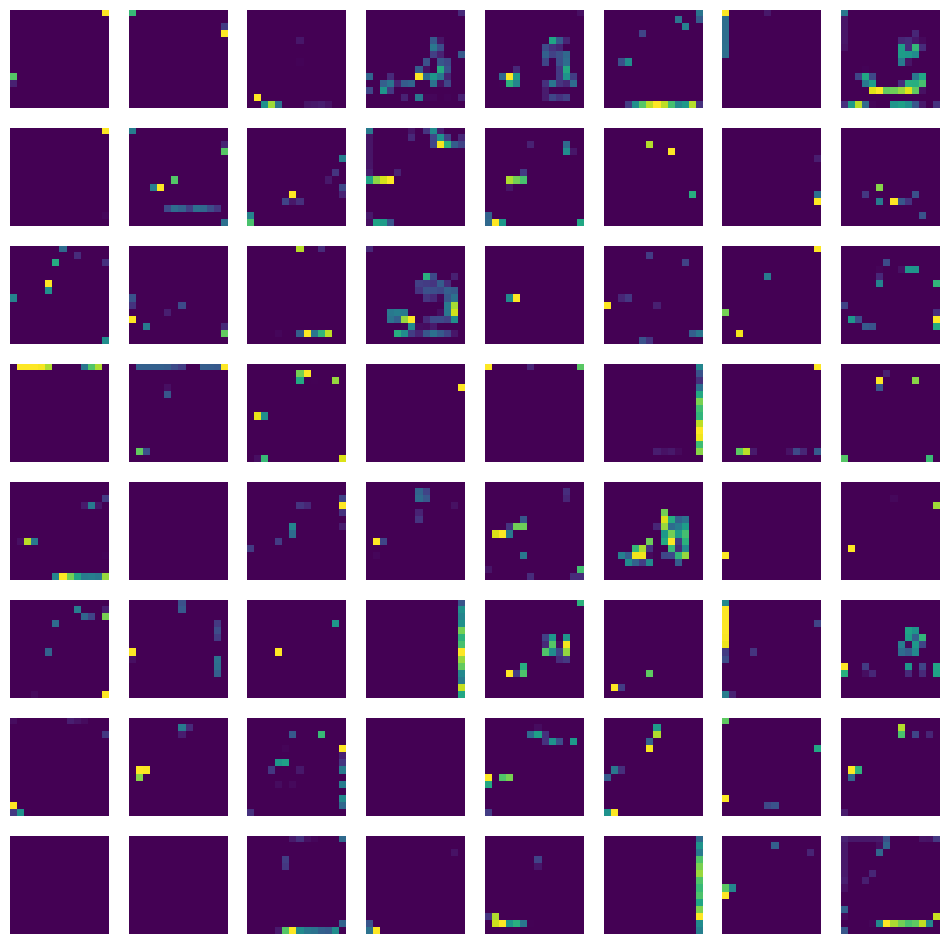

In [84]:
fig, axs = plt.subplots(8, 8, figsize=(12,12))
for i in range(8):
    for j in range(8):
          axs[i, j].imshow(feature_maps[0,:,:,i*8 + j])
          axs[i, j].axis('off')
plt.show()
